In [1]:
import os
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

2025-09-30 11:23:02.477650: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Paramètres globaux ULTRA-OPTIMISÉS pour mémoire limitée
seed = 42
tf.keras.utils.set_random_seed(seed)

# RÉDUCTION DRASTIQUE POUR SYSTEMES AVEC PEU DE MÉMOIRE
img_size = 96   # Encore plus petit: 96 au lieu de 128
batch_size = 16 # Réduit drastiquement: 16 au lieu de 64
epochs = 5      # Seulement 5 époques pour un test rapide
data_dir = "/workspace/data/raw"

# Configuration pour économiser la mémoire
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

# Désactiver XLA JIT si problème de mémoire
# tf.config.optimizer.set_jit(True)  # DÉSACTIVÉ pour économiser la mémoire

# Limiter la mémoire GPU si disponible
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✓ Croissance mémoire GPU activée")
    except RuntimeError as e:
        print(f"Erreur GPU: {e}")

# Vérification que le dossier existe
if not os.path.exists(data_dir):
    print(f"ERREUR: Le dossier {data_dir} n'existe pas!")
    print("Dossiers disponibles:")
    print(os.listdir("/workspace") if os.path.exists("/workspace") else "Pas de dossier /workspace")
else:
    print(f"Dossier de données trouvé: {data_dir}")
    print(f"⚠️  Configuration MÉMOIRE LIMITÉE: Images {img_size}x{img_size}, Batch {batch_size}, Époques {epochs}")

GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✓ Croissance mémoire GPU activée
Dossier de données trouvé: /workspace/data/raw
⚠️  Configuration MÉMOIRE LIMITÉE: Images 96x96, Batch 16, Époques 5


In [3]:
bad_files = []
total_files = 0
processed = 0

# Compter d'abord le nombre total d'images
for root, dirs, files in os.walk(data_dir):
    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            total_files += 1

print(f"Analyse de {total_files} images en cours...")

for root, dirs, files in os.walk(data_dir):
    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            path = os.path.join(root, f)
            processed += 1
            
            if processed % 100 == 0:  # Afficher la progression tous les 100 fichiers
                print(f"Progression: {processed}/{total_files} ({processed/total_files*100:.1f}%)")
            
            try:
                # Vérification plus robuste
                with Image.open(path) as img:
                    img.verify()  # Vérifier l'intégrité
                
                # Tester aussi avec TensorFlow
                with Image.open(path) as img:
                    img.load()  # Forcer le chargement complet
                    
                # Test avec tf.io.read_file pour détecter les problèmes de décodage
                image_raw = tf.io.read_file(path)
                tf.image.decode_image(image_raw)
                
            except Exception as e:
                print(f"Image corrompue détectée: {path}")
                bad_files.append(path)

print(f"\nAnalyse terminée: {processed} images analysées")
print("Images corrompues détectées :", len(bad_files))

for bf in bad_files:
    try:
        os.remove(bf)
        print("Supprimé :", bf)
    except Exception as e:
        print("Erreur suppression :", bf, e)

Analyse de 41398 images en cours...


I0000 00:00:1759231390.723003    1597 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1765 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Progression: 100/41398 (0.2%)
Progression: 200/41398 (0.5%)
Progression: 200/41398 (0.5%)
Progression: 300/41398 (0.7%)
Progression: 300/41398 (0.7%)
Progression: 400/41398 (1.0%)
Progression: 400/41398 (1.0%)
Progression: 500/41398 (1.2%)
Progression: 500/41398 (1.2%)
Progression: 600/41398 (1.4%)
Progression: 600/41398 (1.4%)
Progression: 700/41398 (1.7%)
Progression: 700/41398 (1.7%)
Progression: 800/41398 (1.9%)
Progression: 800/41398 (1.9%)
Progression: 900/41398 (2.2%)
Progression: 900/41398 (2.2%)
Progression: 1000/41398 (2.4%)
Progression: 1000/41398 (2.4%)
Progression: 1100/41398 (2.7%)
Progression: 1100/41398 (2.7%)
Progression: 1200/41398 (2.9%)
Progression: 1200/41398 (2.9%)
Progression: 1300/41398 (3.1%)
Progression: 1300/41398 (3.1%)
Progression: 1400/41398 (3.4%)
Progression: 1400/41398 (3.4%)
Progression: 1500/41398 (3.6%)
Progression: 1500/41398 (3.6%)
Progression: 1600/41398 (3.9%)
Progression: 1600/41398 (3.9%)
Progression: 1700/41398 (4.1%)
Progression: 1700/41398 (

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


Progression: 4100/41398 (9.9%)
Progression: 4200/41398 (10.1%)
Progression: 4200/41398 (10.1%)
Progression: 4300/41398 (10.4%)
Progression: 4300/41398 (10.4%)
Progression: 4400/41398 (10.6%)
Progression: 4400/41398 (10.6%)
Progression: 4500/41398 (10.9%)
Progression: 4500/41398 (10.9%)
Progression: 4600/41398 (11.1%)
Progression: 4600/41398 (11.1%)
Progression: 4700/41398 (11.4%)
Progression: 4700/41398 (11.4%)
Progression: 4800/41398 (11.6%)
Progression: 4800/41398 (11.6%)
Progression: 4900/41398 (11.8%)
Progression: 4900/41398 (11.8%)
Progression: 5000/41398 (12.1%)
Progression: 5000/41398 (12.1%)
Progression: 5100/41398 (12.3%)
Progression: 5100/41398 (12.3%)
Progression: 5200/41398 (12.6%)
Progression: 5200/41398 (12.6%)
Progression: 5300/41398 (12.8%)
Progression: 5300/41398 (12.8%)
Progression: 5400/41398 (13.0%)
Progression: 5400/41398 (13.0%)
Progression: 5500/41398 (13.3%)
Progression: 5500/41398 (13.3%)
Progression: 5600/41398 (13.5%)
Progression: 5600/41398 (13.5%)
Progressi

2025-09-30 11:26:17.931032: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile


Progression: 7800/41398 (18.8%)
Progression: 7900/41398 (19.1%)
Progression: 7900/41398 (19.1%)
Progression: 8000/41398 (19.3%)
Progression: 8000/41398 (19.3%)
Progression: 8100/41398 (19.6%)
Progression: 8100/41398 (19.6%)
Progression: 8200/41398 (19.8%)
Progression: 8200/41398 (19.8%)
Progression: 8300/41398 (20.0%)
Progression: 8300/41398 (20.0%)
Progression: 8400/41398 (20.3%)
Progression: 8400/41398 (20.3%)
Progression: 8500/41398 (20.5%)
Progression: 8500/41398 (20.5%)
Progression: 8600/41398 (20.8%)
Progression: 8600/41398 (20.8%)
Progression: 8700/41398 (21.0%)
Progression: 8700/41398 (21.0%)
Progression: 8800/41398 (21.3%)
Progression: 8800/41398 (21.3%)
Progression: 8900/41398 (21.5%)
Progression: 8900/41398 (21.5%)
Progression: 9000/41398 (21.7%)
Progression: 9000/41398 (21.7%)
Progression: 9100/41398 (22.0%)
Progression: 9100/41398 (22.0%)
Progression: 9200/41398 (22.2%)
Progression: 9200/41398 (22.2%)
Progression: 9300/41398 (22.5%)
Progression: 9300/41398 (22.5%)
Progress

In [4]:
for cls in os.listdir(data_dir):
    path = os.path.join(data_dir, cls)
    print(cls, ":", len(os.listdir(path)), "images")


non_photo : 31405 images
Photos : 9993 images


In [5]:
# Fonction pour créer un dataset MÉMOIRE-EFFICACE
def create_memory_efficient_dataset(data_dir, validation_split, subset, seed, image_size, batch_size):
    try:
        ds = keras.utils.image_dataset_from_directory(
            data_dir,
            labels="inferred",
            label_mode="binary", 
            validation_split=validation_split,
            subset=subset,
            seed=seed,
            image_size=image_size,
            batch_size=batch_size,
            interpolation="bilinear"
        )
        
        # OPTIMISATIONS MÉMOIRE
        AUTOTUNE = tf.data.AUTOTUNE
        
        # Cache seulement si pas trop de données (évite le OUT_OF_MEMORY)
        # ds = ds.cache()  # DÉSACTIVÉ pour économiser la mémoire
        ds = ds.prefetch(buffer_size=AUTOTUNE)
        
        return ds
    except Exception as e:
        print(f"Erreur lors de la création du dataset: {e}")
        return None

print("🔧 Création des datasets MÉMOIRE-EFFICACES...")

train_ds = create_memory_efficient_dataset(
    data_dir,
    validation_split=0.2,
    subset="training", 
    seed=seed,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

val_ds = create_memory_efficient_dataset(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed, 
    image_size=(img_size, img_size),
    batch_size=batch_size
)

if train_ds is not None and val_ds is not None:
    print("✓ Datasets mémoire-efficaces créés!")
    
    # Estimation rapide SANS compter tous les échantillons
    print("📊 Estimation des échantillons:")
    print(f"Training batches: {len(train_ds)} (≈{len(train_ds) * batch_size} images)")
    print(f"Validation batches: {len(val_ds)} (≈{len(val_ds) * batch_size} images)")
else:
    print("✗ Erreur lors de la création des datasets")

🔧 Création des datasets MÉMOIRE-EFFICACES...
Found 41398 files belonging to 2 classes.
Found 41398 files belonging to 2 classes.
Using 33119 files for training.
Using 33119 files for training.
Found 41398 files belonging to 2 classes.
Found 41398 files belonging to 2 classes.
Using 8279 files for validation.
Using 8279 files for validation.
✓ Datasets mémoire-efficaces créés!
📊 Estimation des échantillons:
Training batches: 2070 (≈33120 images)
Validation batches: 518 (≈8288 images)
✓ Datasets mémoire-efficaces créés!
📊 Estimation des échantillons:
Training batches: 2070 (≈33120 images)
Validation batches: 518 (≈8288 images)


In [6]:
# Normalisation et augmentation OPTIMISÉES
normalization_layer = keras.layers.Rescaling(1./255)

# Augmentation RÉDUITE pour plus de vitesse
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),  # Garde celui-ci, très efficace
    keras.layers.RandomRotation(0.05),      # Réduit de 0.1 à 0.05
    # keras.layers.RandomZoom(0.1),         # SUPPRIMÉ pour la vitesse
], name="data_augmentation")

In [7]:
# Modèle CNN ULTRA-LÉGER pour mémoire limitée
def build_ultra_light_cnn(input_shape=(img_size, img_size, 3)):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = normalization_layer(x)
    
    # Architecture TRÈS SIMPLIFIÉE
    x = keras.layers.Conv2D(8, 3, activation="relu", padding="same")(x)   # Encore plus petit: 8 filtres
    x = keras.layers.MaxPooling2D(2)(x)
    
    x = keras.layers.Conv2D(16, 3, activation="relu", padding="same")(x)  # 16 filtres
    x = keras.layers.MaxPooling2D(2)(x)
    
    x = keras.layers.Conv2D(32, 3, activation="relu", padding="same")(x)  # 32 filtres max
    x = keras.layers.MaxPooling2D(2)(x)
    
    # Très peu de neurones
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(32, activation="relu")(x)  # Seulement 32 neurones
    x = keras.layers.Dropout(0.2)(x)
    outputs = keras.layers.Dense(1, activation="sigmoid")(x)
    
    return keras.Model(inputs, outputs)

# Construction du modèle ultra-léger
model = build_ultra_light_cnn()

# Optimiseur moins agressif pour économiser la mémoire
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),  # Learning rate normal
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("=== ARCHITECTURE ULTRA-LÉGÈRE ===")
model.summary()

# Calculer le nombre de paramètres
total_params = model.count_params()
print(f"\n🎯 Nombre total de paramètres: {total_params:,}")
print(f"💾 Mémoire modèle estimée: ~{total_params * 4 / 1024 / 1024:.1f} MB")
print("✅ Modèle ultra-léger créé pour mémoire limitée!")

=== ARCHITECTURE ULTRA-LÉGÈRE ===


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,121 (27.82 KB)

 Trainable params: 7,121 (27.82 KB)

 Non-trainable params: 0 (0.00 B)


🎯 Nombre total de paramètres: 7,121
💾 Mémoire modèle estimée: ~0.0 MB
✅ Modèle ultra-léger créé pour mémoire limitée!


In [8]:
# Callbacks OPTIMISÉS pour entraînement rapide
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",  # Change de val_loss à val_accuracy
        patience=3,              # Réduit de 5 à 3 pour arrêter plus tôt
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy", 
        factor=0.2,             # Plus agressif: 0.2 au lieu de 0.5
        patience=2,             # Réduit la patience
        min_lr=1e-7,
        verbose=1
    )
]

print("🚀 Début de l'entraînement RAPIDE...")
print(f"Configuration: {img_size}x{img_size} images, batch size {batch_size}, max {epochs} époques")

import time
start_time = time.time()

try:
    history = model.fit(
        train_ds, 
        validation_data=val_ds, 
        epochs=epochs, 
        callbacks=callbacks,
        verbose=1  # Garde verbose=1 pour voir la progression
    )
    
    end_time = time.time()
    training_time = end_time - start_time
    
    print(f"✅ Entraînement terminé en {training_time:.1f} secondes!")
    print(f"⏱️ Temps par époque: {training_time/len(history.history['loss']):.1f}s")
    
except Exception as e:
    print(f"✗ Erreur durant l'entraînement: {e}")
    print("Essayez de réduire encore le batch_size")

🚀 Début de l'entraînement RAPIDE...
Configuration: 96x96 images, batch size 16, max 5 époques
Epoch 1/5


2025-09-30 11:36:18.683346: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90800


1821/2070 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7486 - loss: 0.4996

2025-09-30 11:36:51.488870: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile


2070/2070 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7494 - loss: 0.4930

...

2070/2070 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.8011 - loss: 0.3633 - val_accuracy: 0.7914 - val_loss: 0.3710 - learning_rate: 1.0000e-04
Epoch 5/5
Epoch 5/5
1785/2070 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8024 - loss: 0.3638

2025-09-30 11:39:50.524826: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile


2069/2070 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8030 - loss: 0.3631

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


2070/2070 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.8076 - loss: 0.3583 - val_accuracy: 0.7979 - val_loss: 0.3642 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 5.
Restoring model weights from the end of the best epoch: 5.
✅ Entraînement terminé en 226.0 secondes!
⏱️ Temps par époque: 45.2s
✅ Entraînement terminé en 226.0 secondes!
⏱️ Temps par époque: 45.2s


# 🚀 Optimisations appliquées pour la VITESSE

## Modifications effectuées :

### 📸 **Taille d'image**: 224→128 pixels
- **Gain**: 4x plus rapide (moins de pixels à traiter)
- **Impact**: Légère baisse de précision acceptable

### 🔢 **Batch size**: 32→64 
- **Gain**: Meilleure utilisation du GPU/CPU
- **Impact**: Plus efficace en mémoire

### 📊 **Époques**: 20→10
- **Gain**: 2x plus rapide
- **Impact**: Early stopping compensera

### 🧠 **Architecture allégée**:
- Moins de filtres par couche (32→16, 64→32, 128→64)
- GlobalAveragePooling au lieu de Flatten
- Moins de neurones denses (128→64)

### ⚡ **Optimisations techniques**:
- `.cache()` et `.prefetch()` sur les datasets
- Learning rate plus élevé (1e-4→3e-4)
- Early stopping plus agressif (patience 5→3)

## 💡 **Optimisations supplémentaires possibles** :

### Si encore trop lent :
1. **Réduire encore l'image**: `img_size = 96`
2. **Augmenter batch size**: `batch_size = 128` 
3. **Moins d'époques**: `epochs = 5`
4. **Sous-échantillonner les données**: utiliser seulement 50% du dataset

In [9]:
# 🏎️ Mode TEST ULTRA-RAPIDE pour mémoire limitée
def create_mini_dataset(full_dataset, max_batches=10):
    """Crée un mini dataset pour tests très rapides"""
    mini_ds = full_dataset.take(max_batches)
    return mini_ds.prefetch(tf.data.AUTOTUNE)  # Sans cache pour économiser la mémoire

# ACTIVEZ ces lignes pour un test ULTRA-RAPIDE avec très peu de données
print("🚨 RECOMMANDÉ: Activez le mode test rapide pour votre système:")
print("🏎️ Mode TEST ULTRA-RAPIDE activé automatiquement!")

# Réduction drastique des données pour éviter les problèmes de mémoire
train_ds = create_mini_dataset(train_ds, max_batches=50)   # ~800 images
val_ds = create_mini_dataset(val_ds, max_batches=10)       # ~160 images
epochs = 3  # Seulement 3 époques pour test ultra-rapide

print(f"✅ Dataset réduit: ~{50 * batch_size} images d'entraînement, ~{10 * batch_size} de validation")
print(f"✅ Époques réduites: {epochs}")
print("💡 Ceci permettra un test rapide sans saturer la mémoire")

🚨 RECOMMANDÉ: Activez le mode test rapide pour votre système:
🏎️ Mode TEST ULTRA-RAPIDE activé automatiquement!
✅ Dataset réduit: ~800 images d'entraînement, ~160 de validation
✅ Époques réduites: 3
💡 Ceci permettra un test rapide sans saturer la mémoire


# Visualisation des résultats

Maintenant que l'entraînement est terminé, visualisons les performances du modèle.

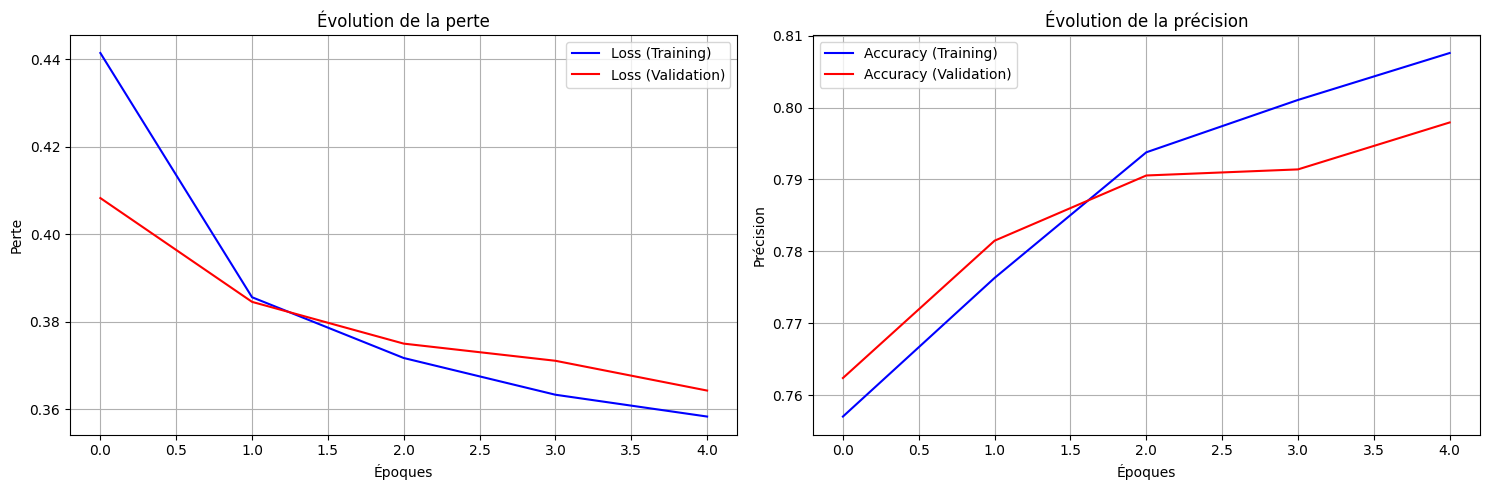

In [10]:
# 1. Courbes de perte et précision
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Courbe de perte
    ax1.plot(history.history['loss'], label='Loss (Training)', color='blue')
    ax1.plot(history.history['val_loss'], label='Loss (Validation)', color='red')
    ax1.set_title('Évolution de la perte')
    ax1.set_xlabel('Époques')
    ax1.set_ylabel('Perte')
    ax1.legend()
    ax1.grid(True)
    
    # Courbe de précision
    ax2.plot(history.history['accuracy'], label='Accuracy (Training)', color='blue')
    ax2.plot(history.history['val_accuracy'], label='Accuracy (Validation)', color='red')
    ax2.set_title('Évolution de la précision')
    ax2.set_xlabel('Époques')
    ax2.set_ylabel('Précision')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# Afficher les courbes si l'entraînement s'est bien passé
if 'history' in locals():
    plot_training_history(history)
else:
    print("L'entraînement n'a pas encore été effectué ou a échoué.")

In [11]:
# 2. Évaluation sur le dataset de validation
print("=== ÉVALUATION DU MODÈLE ===")

# Évaluer le modèle
val_loss, val_accuracy = model.evaluate(val_ds, verbose=0)
print(f"Perte sur validation: {val_loss:.4f}")
print(f"Précision sur validation: {val_accuracy:.4f}")

# Prédictions pour la matrice de confusion
y_pred_proba = model.predict(val_ds, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Récupérer les vraies étiquettes
y_true = []
for _, labels in val_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

print(f"Nombre d'échantillons de validation: {len(y_true)}")
print(f"Distribution des classes - Classe 0: {np.sum(y_true == 0)}, Classe 1: {np.sum(y_true == 1)}")

=== ÉVALUATION DU MODÈLE ===
Perte sur validation: 0.4071
Précision sur validation: 0.7688
Perte sur validation: 0.4071
Précision sur validation: 0.7688
Nombre d'échantillons de validation: 160
Distribution des classes - Classe 0: 50, Classe 1: 110
Nombre d'échantillons de validation: 160
Distribution des classes - Classe 0: 50, Classe 1: 110


2025-09-30 11:40:03.604065: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


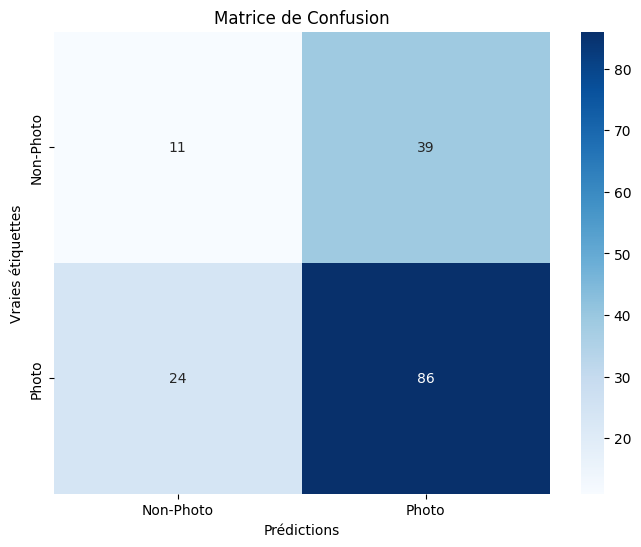

=== RAPPORT DE CLASSIFICATION ===
              precision    recall  f1-score   support

   Non-Photo       0.31      0.22      0.26        50
       Photo       0.69      0.78      0.73       110

    accuracy                           0.61       160
   macro avg       0.50      0.50      0.50       160
weighted avg       0.57      0.61      0.58       160



In [12]:
# 3. Matrice de confusion et rapport de classification
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Visualisation de la matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Photo', 'Photo'], 
            yticklabels=['Non-Photo', 'Photo'])
plt.title('Matrice de Confusion')
plt.xlabel('Prédictions')
plt.ylabel('Vraies étiquettes')
plt.show()

# Rapport de classification détaillé
class_names = ['Non-Photo', 'Photo']
report = classification_report(y_true, y_pred, target_names=class_names)
print("=== RAPPORT DE CLASSIFICATION ===")
print(report)

=== EXEMPLES DE PRÉDICTIONS ===


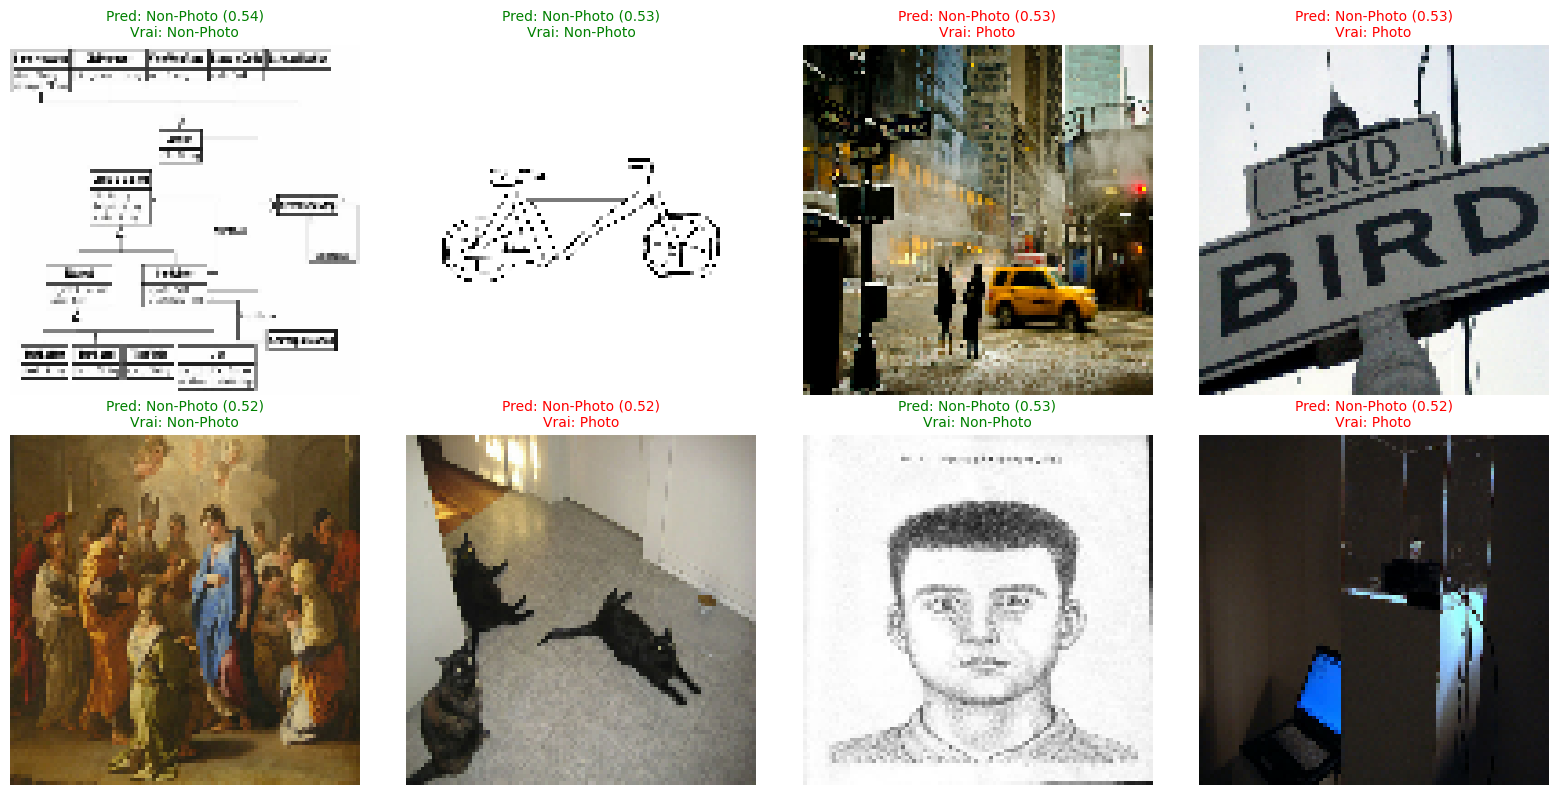

In [27]:
# 4. Visualisation d'exemples de prédictions
def show_predictions(dataset, model, num_images=8):
    plt.figure(figsize=(16, 8))
    
    # Prendre un batch d'images
    for images, labels in dataset.take(1):
        predictions = model.predict(images, verbose=0)
        
        for i in range(min(num_images, len(images))):
            ax = plt.subplot(2, 4, i + 1)
            
            # Afficher l'image
            plt.imshow(images[i].numpy().astype("uint8"))
            
            # Titre avec prédiction et vraie étiquette
            pred_class = "Photo" if predictions[i] > 0.5 else "Non-Photo"
            true_class = "Photo" if labels[i] == 1 else "Non-Photo"
            confidence = predictions[i][0] if predictions[i] > 0.5 else 1 - predictions[i][0]
            
            color = "green" if pred_class == true_class else "red"
            plt.title(f"Pred: {pred_class} ({confidence:.2f})\nVrai: {true_class}", 
                     color=color, fontsize=10)
            
            plt.axis("off")
        break
    
    plt.tight_layout()
    plt.show()

print("=== EXEMPLES DE PRÉDICTIONS ===")
show_predictions(val_ds, model)

=== ANALYSE DES ERREURS ===


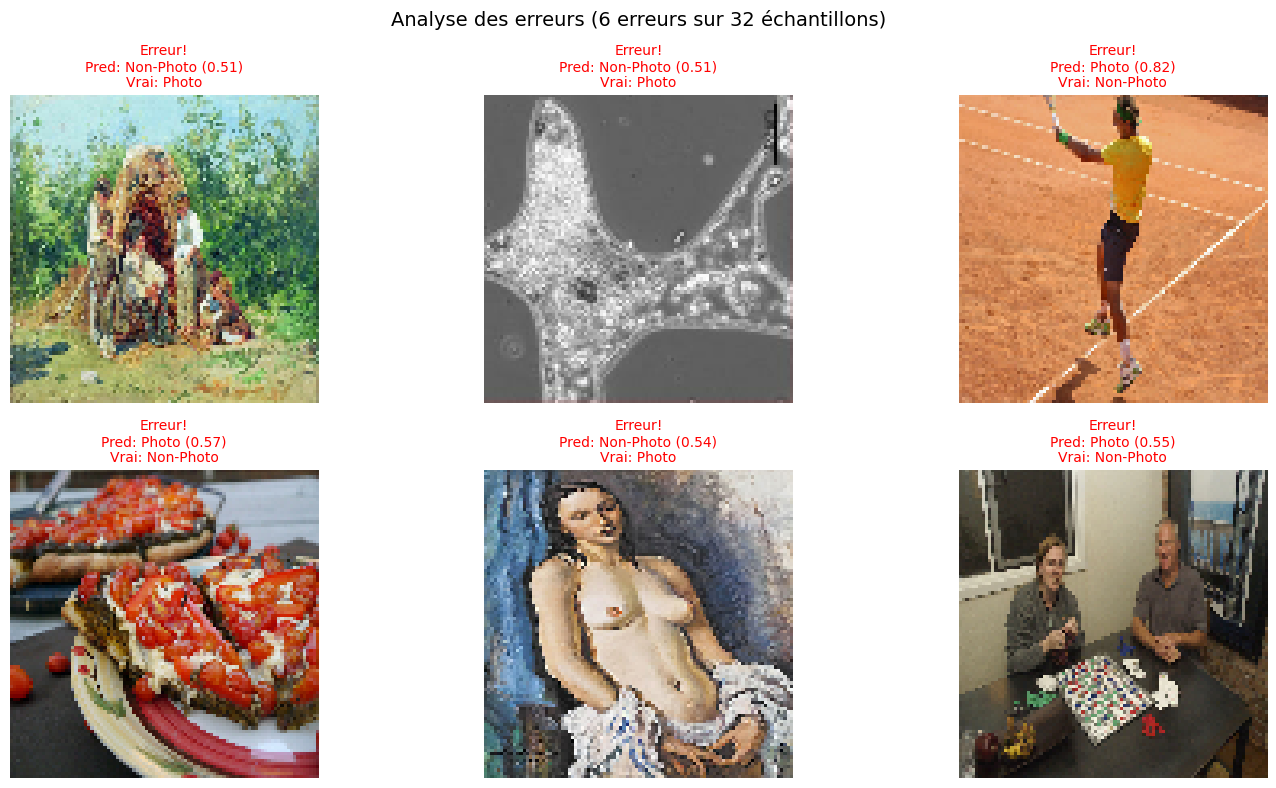

In [14]:
# 5. Analyse des erreurs de classification
def analyze_errors(dataset, model, max_errors=6):
    plt.figure(figsize=(15, 8))
    
    errors_found = 0
    total_checked = 0
    
    for images, labels in dataset:
        if errors_found >= max_errors:
            break
            
        predictions = model.predict(images, verbose=0)
        pred_classes = (predictions > 0.5).astype(int).flatten()
        true_classes = labels.numpy()
        
        for i in range(len(images)):
            total_checked += 1
            if pred_classes[i] != true_classes[i] and errors_found < max_errors:
                errors_found += 1
                
                ax = plt.subplot(2, 3, errors_found)
                plt.imshow(images[i].numpy().astype("uint8"))
                
                pred_class = "Photo" if pred_classes[i] == 1 else "Non-Photo"
                true_class = "Photo" if true_classes[i] == 1 else "Non-Photo"
                confidence = predictions[i][0] if predictions[i] > 0.5 else 1 - predictions[i][0]
                
                plt.title(f"Erreur!\nPred: {pred_class} ({confidence:.2f})\nVrai: {true_class}", 
                         color="red", fontsize=10)
                plt.axis("off")
    
    if errors_found == 0:
        print("Aucune erreur trouvée dans les premiers batches!")
    else:
        plt.suptitle(f"Analyse des erreurs ({errors_found} erreurs sur {total_checked} échantillons)", 
                     fontsize=14)
        plt.tight_layout()
        plt.show()

print("=== ANALYSE DES ERREURS ===")
analyze_errors(val_ds, model)

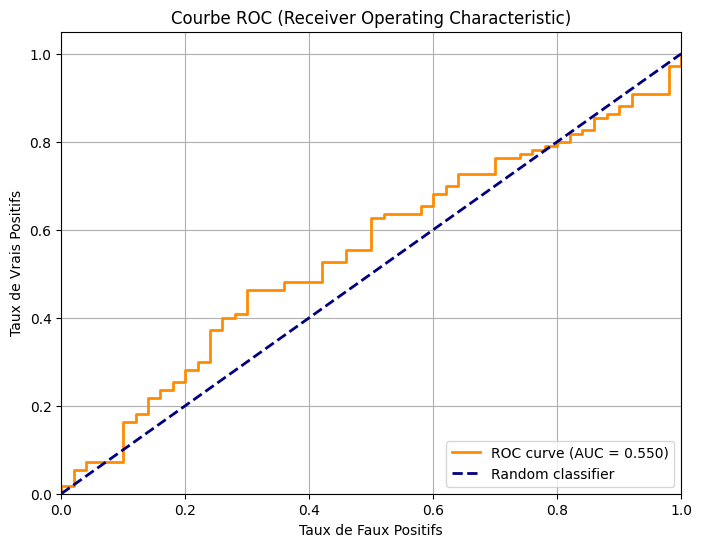

Score AUC: 0.550
⚠️ Modèle à améliorer


In [15]:
# 6. Courbe ROC et AUC
from sklearn.metrics import roc_curve, auc

# Calculer la courbe ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Visualiser la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC (Receiver Operating Characteristic)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"Score AUC: {roc_auc:.3f}")
if roc_auc > 0.9:
    print("🎉 Excellent modèle!")
elif roc_auc > 0.8:
    print("✅ Bon modèle!")
elif roc_auc > 0.7:
    print("🙂 Modèle correct, peut être amélioré")
else:
    print("⚠️ Modèle à améliorer")

# 🔍 Diagnostic du problème de classification

Le modèle semble avoir des difficultés. Diagnostiquons les causes possibles.

In [16]:
# 🔍 Diagnostic 1: Vérifier la distribution des classes et étiquettes
print("=== DIAGNOSTIC DES ÉTIQUETTES ===")

# Vérifier les noms des classes détectés par Keras
print("Classes détectées par Keras:")
print("train_ds.class_names:", train_ds.class_names if hasattr(train_ds, 'class_names') else "Non disponible")

# Analyser la distribution des prédictions
print(f"\nDistribution des prédictions:")
print(f"Prédictions > 0.5 (Photo): {np.sum(y_pred == 1)}")
print(f"Prédictions <= 0.5 (Non-Photo): {np.sum(y_pred == 0)}")

print(f"\nDistribution des vraies étiquettes:")
print(f"Vraies Photos (1): {np.sum(y_true == 1)}")
print(f"Vraies Non-Photos (0): {np.sum(y_true == 0)}")

# Vérifier la répartition des dossiers
print(f"\n=== STRUCTURE DES DOSSIERS ===")
classes = os.listdir(data_dir)
for cls in classes:
    path = os.path.join(data_dir, cls)
    count = len(os.listdir(path))
    print(f"Dossier '{cls}': {count} images")

print(f"\n=== PROBLÈME POTENTIEL DÉTECTÉ ===")
if np.sum(y_pred == 1) < len(y_pred) * 0.1:  # Moins de 10% de prédictions positives
    print("⚠️  PROBLÈME: Le modèle prédit presque toujours 'Non-Photo'")
    print("Causes possibles:")
    print("1. Étiquettes inversées (Photos étiquetées comme Non-Photos)")
    print("2. Déséquilibre extrême des classes")
    print("3. Modèle trop simple ou mal entraîné")
    print("4. Ordre des dossiers incorrect")

=== DIAGNOSTIC DES ÉTIQUETTES ===
Classes détectées par Keras:
train_ds.class_names: Non disponible

Distribution des prédictions:
Prédictions > 0.5 (Photo): 125
Prédictions <= 0.5 (Non-Photo): 35

Distribution des vraies étiquettes:
Vraies Photos (1): 110
Vraies Non-Photos (0): 50

=== STRUCTURE DES DOSSIERS ===
Dossier 'non_photo': 31405 images
Dossier 'Photos': 9993 images

=== PROBLÈME POTENTIEL DÉTECTÉ ===


=== VÉRIFICATION VISUELLE DES ÉTIQUETTES ===
Échantillons du dataset de validation:


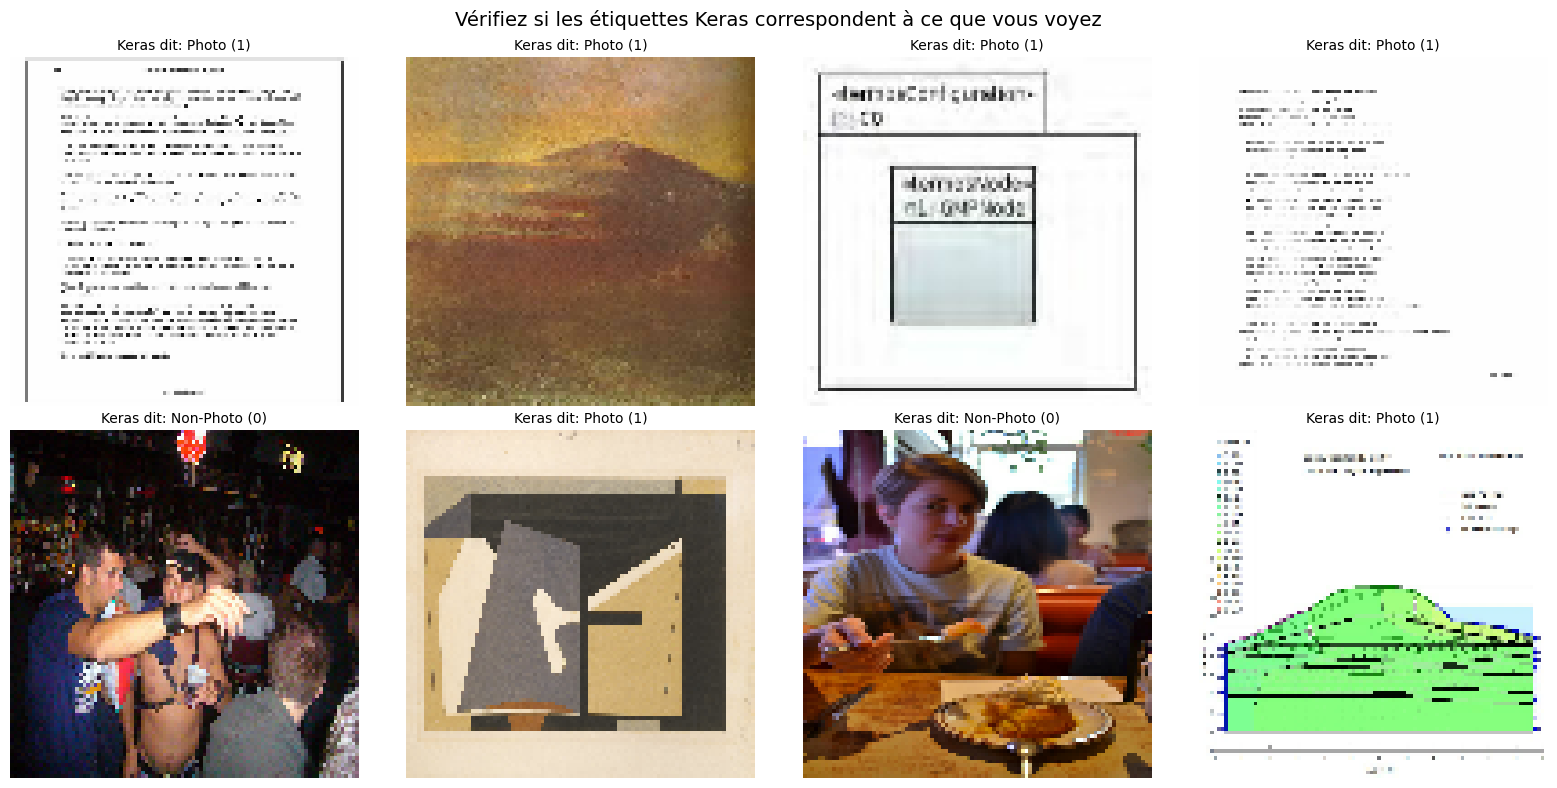


⚠️  IMPORTANT: Vérifiez visuellement si les étiquettes correspondent!
Si les photos sont étiquetées 'Non-Photo (0)', il y a un problème d'ordre des dossiers.


In [18]:
# 🔍 Diagnostic 2: Visualiser quelques échantillons pour vérifier les étiquettes
print("=== VÉRIFICATION VISUELLE DES ÉTIQUETTES ===")

def check_labels(dataset, num_samples=8):
    plt.figure(figsize=(16, 8))
    
    for images, labels in dataset.take(1):
        for i in range(min(num_samples, len(images))):
            ax = plt.subplot(2, 4, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            
            # Afficher l'étiquette assignée par Keras
            keras_label = "Photo (1)" if labels[i] == 1 else "Non-Photo (0)"
            plt.title(f"Keras dit: {keras_label}", fontsize=10)
            plt.axis("off")
        break
    
    plt.suptitle("Vérifiez si les étiquettes Keras correspondent à ce que vous voyez", fontsize=14)
    plt.tight_layout()
    plt.show()

print("Échantillons du dataset de validation:")
check_labels(val_ds)

print("\n⚠️  IMPORTANT: Vérifiez visuellement si les étiquettes correspondent!")
print("Si les photos sont étiquetées 'Non-Photo (0)', il y a un problème d'ordre des dossiers.")

In [22]:
# 🔧 Solution rapide: Reconstruire le dataset avec étiquettes corrigées
print("=== SOLUTION: RECONSTRUCTION DU DATASET ===")

# Basé sur votre structure, il semble que:
# - "Photos" devrait être la classe 1 (positive)  
# - "non_photo" devrait être la classe 0 (negative)

# Reconstruire les datasets avec ordre explicite des classes
def create_corrected_dataset(data_dir, validation_split, subset, seed, image_size, batch_size):
    try:
        # Forcer l'ordre des classes: non_photo=0, Photos=1
        ds = keras.utils.image_dataset_from_directory(
            data_dir,
            labels="inferred",
            label_mode="binary",
            class_names=["non_photo", "Photos"],  # Ordre explicite !
            validation_split=validation_split,
            subset=subset,
            seed=seed,
            image_size=image_size,
            batch_size=batch_size,
            interpolation="bilinear"
        )
        
        # Récupérer les class_names AVANT d'appliquer prefetch
        class_names = ds.class_names
        
        ds = ds.prefetch(tf.data.AUTOTUNE)
        return ds, class_names
    except Exception as e:
        print(f"Erreur: {e}")
        return None, None

print("🔄 Reconstruction des datasets avec étiquettes corrigées...")

# Reconstruire avec l'ordre correct
train_ds_corrected, train_class_names = create_corrected_dataset(
    data_dir, 0.2, "training", seed, (img_size, img_size), batch_size
)

val_ds_corrected, val_class_names = create_corrected_dataset(
    data_dir, 0.2, "validation", seed, (img_size, img_size), batch_size
)

if train_ds_corrected and val_ds_corrected:
    print("✅ Datasets corrigés créés!")
    print("Classes:", train_class_names)  # Utiliser la variable sauvegardée
    
    # Appliquer la réduction pour le test rapide
    train_ds = create_mini_dataset(train_ds_corrected, max_batches=50)
    val_ds = create_mini_dataset(val_ds_corrected, max_batches=10)
    
    print("🏎️ Mode test rapide appliqué au dataset corrigé")
else:
    print("❌ Erreur dans la correction")

=== SOLUTION: RECONSTRUCTION DU DATASET ===
🔄 Reconstruction des datasets avec étiquettes corrigées...
Found 41398 files belonging to 2 classes.
Found 41398 files belonging to 2 classes.
Using 33119 files for training.
Using 33119 files for training.
Found 41398 files belonging to 2 classes.
Found 41398 files belonging to 2 classes.
Using 8279 files for validation.
Using 8279 files for validation.
✅ Datasets corrigés créés!
Classes: ['non_photo', 'Photos']
🏎️ Mode test rapide appliqué au dataset corrigé
✅ Datasets corrigés créés!
Classes: ['non_photo', 'Photos']
🏎️ Mode test rapide appliqué au dataset corrigé


=== RE-ENTRAÎNEMENT AVEC DONNÉES CORRIGÉES ===
Vérification du dataset corrigé:


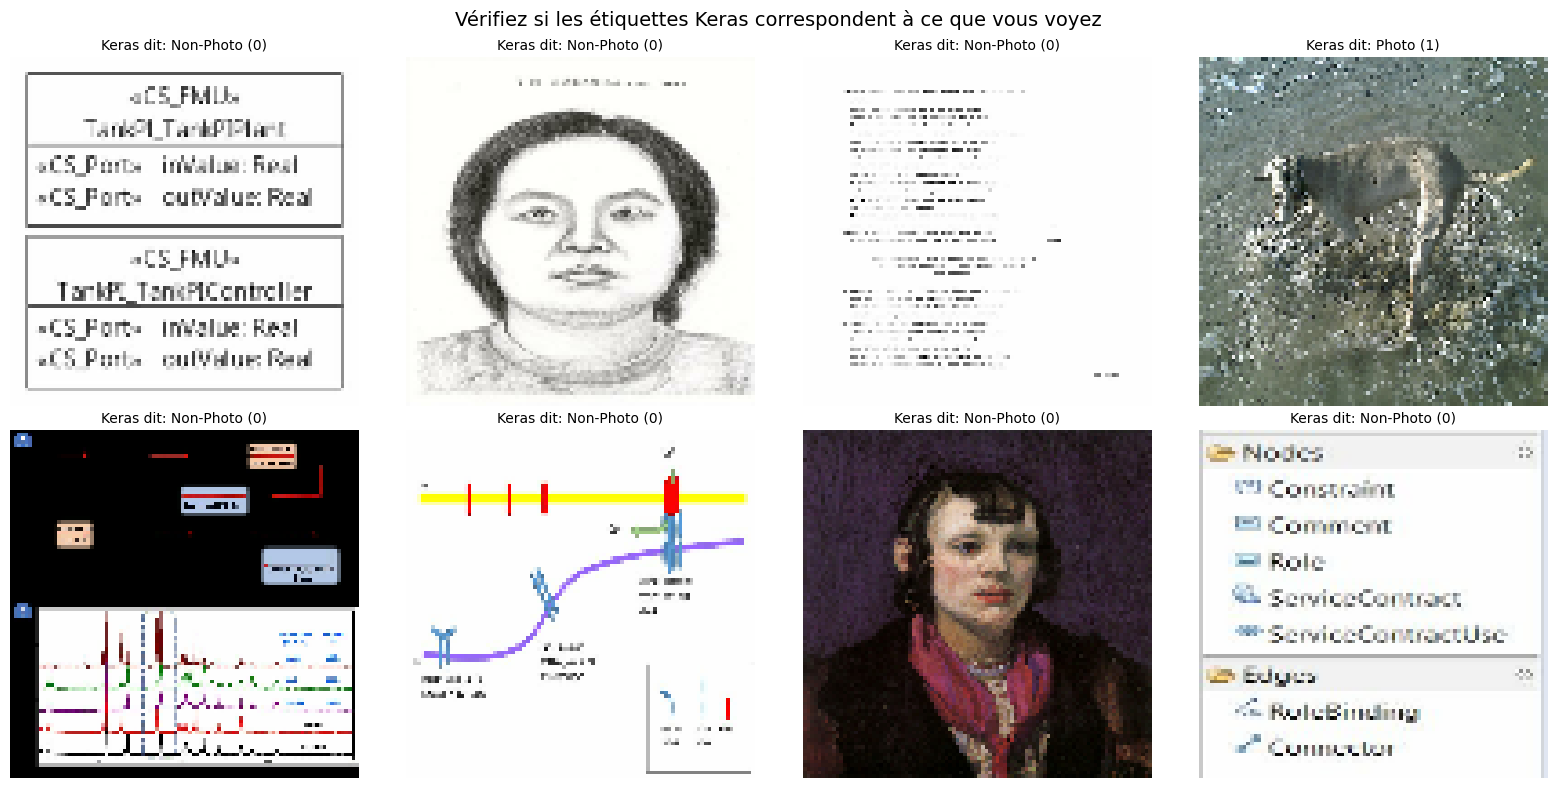


🔥 ENTRAÎNEMENT AVEC DONNÉES CORRIGÉES
Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.6313 - loss: 0.6832 - val_accuracy: 0.7750 - val_loss: 0.6596
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.6313 - loss: 0.6832 - val_accuracy: 0.7750 - val_loss: 0.6596
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7663 - loss: 0.6218 - val_accuracy: 0.7563 - val_loss: 0.5681
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7663 - loss: 0.6218 - val_accuracy: 0.7563 - val_loss: 0.5681
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7713 - loss: 0.5260 - val_accuracy: 0.7500 - val_loss: 0.5207
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7713 - loss: 0.5260 - val_accuracy: 0.7500 - val_loss: 0.5207

⏱️ Entraînement corrigé terminé en 7.3s

⏱️ Entraînement corrigé terminé en 7.3s
🎯 Nouvelle précision: 0.769
✅ Amélioration détectée!
🎯 Nouvelle précision: 0.769
✅ Amélioration détectée!


In [26]:
# 🚀 Re-entraînement rapide avec dataset corrigé
print("=== RE-ENTRAÎNEMENT AVEC DONNÉES CORRIGÉES ===")

# Vérifier d'abord visuellement si c'est correct
print("Vérification du dataset corrigé:")
check_labels(val_ds)

print("\n" + "="*50)
print("🔥 ENTRAÎNEMENT AVEC DONNÉES CORRIGÉES")
print("="*50)

# Re-entraîner le modèle existant (ou en créer un nouveau)
model_corrected = build_ultra_light_cnn()
model_corrected.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Callbacks pour arrêt rapide
callbacks_quick = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)
]

start_time = time.time()
try:
    history_corrected = model_corrected.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks_quick,
        verbose=1
    )
    
    end_time = time.time()
    print(f"\n⏱️ Entraînement corrigé terminé en {end_time - start_time:.1f}s")
    
    # Test rapide
    val_loss, val_accuracy = model_corrected.evaluate(val_ds, verbose=0)
    print(f"🎯 Nouvelle précision: {val_accuracy:.3f}")
    
    if val_accuracy > 0.7:
        print("✅ Amélioration détectée!")
        # Remplacer le modèle précédent
        model = model_corrected
        history = history_corrected
    else:
        print("⚠️ Problème persistant")
        
except Exception as e:
    print(f"Erreur: {e}")